<a href="https://colab.research.google.com/github/AnnabelleMcSharry/AI-ML-Car-Data/blob/main/Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [148]:
import pandas as pd

Cars= pd.read_csv("CarDataset.csv",index_col=False, names = ["S.No.", "Name", "Location", "Year", "Kilometers_Driven", "Fuel_Type", "Transmission", "Owner_Type", "Mileage", "Engine"])

print(Cars.head())


   S.No.                              Name  Location  Year  Kilometers_Driven  \
0  S.No.                              Name  Location  Year  Kilometers_Driven   
1      0            Maruti Wagon R LXI CNG    Mumbai  2010              72000   
2      1  Hyundai Creta 1.6 CRDi SX Option      Pune  2015              41000   
3      2                      Honda Jazz V   Chennai  2011              46000   
4      3                 Maruti Ertiga VDI   Chennai  2012              87000   

   Fuel_Type  Transmission  Owner_Type     Mileage   Engine  
0  Fuel_Type  Transmission  Owner_Type     Mileage   Engine  
1        CNG        Manual       First  26.6 km/kg   998 CC  
2     Diesel        Manual       First  19.67 kmpl  1582 CC  
3     Petrol        Manual       First   18.2 kmpl  1199 CC  
4     Diesel        Manual       First  20.77 kmpl  1248 CC  


In [149]:
Cars = Cars.drop(["S.No."], axis=1)
print(Cars.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7254 entries, 0 to 7253
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Name               7254 non-null   object
 1   Location           7254 non-null   object
 2   Year               7254 non-null   object
 3   Kilometers_Driven  7254 non-null   object
 4   Fuel_Type          7254 non-null   object
 5   Transmission       7254 non-null   object
 6   Owner_Type         7254 non-null   object
 7   Mileage            7252 non-null   object
 8   Engine             7208 non-null   object
dtypes: object(9)
memory usage: 510.2+ KB
None


In [150]:
Cars = Cars.replace(" ", pd.NA)
print(Cars.isnull().sum())

Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               2
Engine               46
dtype: int64


In [151]:
new_Cars = Cars.dropna()
print("################")
print("Total records that would be lost if deleted : ")
print(Cars.shape[0]- new_Cars.shape[0])
del new_Cars

################
Total records that would be lost if deleted : 
48


In [152]:
print(Cars['Mileage'].value_counts())
print(Cars['Engine'].value_counts())


Mileage
17.0 kmpl     207
18.9 kmpl     201
18.6 kmpl     144
21.1 kmpl     106
20.36 kmpl    105
             ... 
13.44 kmpl      1
23.57 kmpl      1
8.77 kmpl       1
15.56 kmpl      1
17.15 kmpl      1
Name: count, Length: 451, dtype: int64
Engine
1197 CC    732
1248 CC    610
1498 CC    370
998 CC     309
1198 CC    281
          ... 
2112 CC      1
2000 CC      1
1795 CC      1
3696 CC      1
1389 CC      1
Name: count, Length: 151, dtype: int64


In [153]:
Cars = Cars.dropna()

In [154]:
Cars = Cars.iloc[1:].copy() # Drop the first row (the duplicate header)
display(Cars.head()) # Display to confirm the header row is removed


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine
1,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC
2,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC
3,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC
4,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC
5,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC


In [155]:
Cars["Year"] = pd.to_numeric(Cars["Year"])

In [156]:
Cars["Kilometers_Driven"] = pd.to_numeric(Cars["Kilometers_Driven"])

In [157]:
print('Unique units in Mileage:')
print(Cars['Mileage'].apply(lambda x: str(x).split()[-1]).unique())

print('\nUnique units in Engine:')
print(Cars['Engine'].apply(lambda x: str(x).split()[-1]).unique())

Unique units in Mileage:
['km/kg' 'kmpl']

Unique units in Engine:
['CC']


In [158]:
print('Count of each unit in Mileage:')
print(Cars['Mileage'].apply(lambda x: str(x).split()[-1]).value_counts())

Count of each unit in Mileage:
Mileage
kmpl     7131
km/kg      74
Name: count, dtype: int64


In [159]:
print(Cars['Fuel_Type'].unique())

['CNG' 'Diesel' 'Petrol' 'LPG']


In [160]:
Cars = Cars.replace("CNG", pd.NA)
Cars = Cars.replace("LPG", pd.NA)
print(Cars.isnull().sum())

Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type            74
Transmission          0
Owner_Type            0
Mileage               0
Engine                0
dtype: int64


In [161]:
Cars = Cars.dropna()

In [162]:
print('Count of each unit in Mileage:')
print(Cars['Mileage'].apply(lambda x: str(x).split()[-1]).value_counts())

Count of each unit in Mileage:
Mileage
kmpl    7131
Name: count, dtype: int64


In [163]:
Cars = Cars.rename(columns={'Mileage': 'Mileage_kmpl'})

In [164]:
Cars['Mileage_kmpl'] = Cars['Mileage_kmpl'].astype(str).str.split().str[0].astype(float)
display(Cars.head())

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine
2,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582 CC
3,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199 CC
4,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248 CC
5,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968 CC
7,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08,1461 CC


In [165]:
Cars = Cars.rename(columns={'Engine': 'Engine_CC'})

In [166]:
Cars['Engine_CC'] = Cars['Engine_CC'].astype(str).str.split().str[0].astype(int)
display(Cars.head())

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_CC
2,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582
3,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199
4,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248
5,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968
7,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08,1461


In [167]:
print('Unique values and counts for Fuel_Type:')
print(Cars['Fuel_Type'].value_counts())

print('\nUnique values and counts for Transmission:')
print(Cars['Transmission'].value_counts())

print('\nUnique values and counts for Owner_Type:')
print(Cars['Owner_Type'].value_counts())

# For Name and Location, we'll just show the number of unique values due to potentially high cardinality
print('\nNumber of unique car names:', Cars['Name'].nunique())
print('Number of unique locations:', Cars['Location'].nunique())

Unique values and counts for Fuel_Type:
Fuel_Type
Diesel    3840
Petrol    3291
Name: count, dtype: int64

Unique values and counts for Transmission:
Transmission
Manual       5095
Automatic    2036
Name: count, dtype: int64

Unique values and counts for Owner_Type:
Owner_Type
First             5864
Second            1123
Third              133
Fourth & Above      11
Name: count, dtype: int64

Number of unique car names: 1990
Number of unique locations: 11


Based on the unique values:

*   **Fuel_Type**, **Transmission**, and **Location** are nominal categories with low cardinality. **One-Hot Encoding** is the best choice here as it creates new binary columns for each category, avoiding any implied ordinal relationship.
*   **Owner_Type** is an ordinal category ('First', 'Second', 'Third'). **Label Encoding** is suitable as it assigns numerical values (e.g., 0, 1, 2) that preserve the inherent order.
*   **Name** has high cardinality (many unique values). For this, **Label Encoding** can be used to convert it to a numerical representation. While Label Encoding introduces an arbitrary ordinal relationship, it is a practical approach for high-cardinality nominal features to avoid creating an excessively sparse DataFrame if One-Hot Encoding were used.

In [168]:
# One-Hot Encoding for 'Fuel_Type', 'Transmission', and 'Location' (Nominal)
# We are not using `drop_first=True` to ensure explicit columns for all categories.
Cars = pd.get_dummies(Cars, columns=['Transmission', 'Location'], drop_first=False)

display(Cars.head())

,Name,Year,Kilometers_Driven,Fuel_Type,Owner_Type,Mileage_kmpl,Engine_CC,Transmission_Automatic,Transmission_Manual,Location_Ahmedabad,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune
2,Hyundai Creta 1.6 CRDi SX Option,2015,41000,Diesel,First,19.67,1582,False,True,False,False,False,False,False,False,False,False,False,False,True
3,Honda Jazz V,2011,46000,Petrol,First,18.20,1199,False,True,False,False,True,False,False,False,False,False,False,False,False
4,Maruti Ertiga VDI,2012,87000,Diesel,First,20.77,1248,False,True,False,False,True,False,False,False,False,False,False,False,False
5,Audi A4 New 2.0 TDI Multitronic,2013,40670,Diesel,Second,15.20,1968,True,False,False,False,False,True,False,False,False,False,False,False,False
7,Nissan Micra Diesel XV,2013,86999,Diesel,First,23.08,1461,False,True,False,False,False,False,False,False,True,False,False,False,False


In [169]:
owner_type_mapping = {'First': 0, 'Second': 1, 'Third': 2, 'Fourth & Above': 3}
Cars['Owner_Type_Encoded'] = Cars['Owner_Type'].map(owner_type_mapping)

display(Cars[['Owner_Type', 'Owner_Type_Encoded']].head())

,Owner_Type,Owner_Type_Encoded
2,First,0
3,First,0
4,First,0
5,Second,1
7,First,0


In [170]:
Cars = Cars.drop('Owner_Type', axis=1)
display(Cars.head())

,Name,Year,Kilometers_Driven,Fuel_Type,Mileage_kmpl,Engine_CC,Transmission_Automatic,Transmission_Manual,Location_Ahmedabad,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune,Owner_Type_Encoded
2,Hyundai Creta 1.6 CRDi SX Option,2015,41000,Diesel,19.67,1582,False,True,False,False,False,False,False,False,False,False,False,False,True,0
3,Honda Jazz V,2011,46000,Petrol,18.20,1199,False,True,False,False,True,False,False,False,False,False,False,False,False,0
4,Maruti Ertiga VDI,2012,87000,Diesel,20.77,1248,False,True,False,False,True,False,False,False,False,False,False,False,False,0
5,Audi A4 New 2.0 TDI Multitronic,2013,40670,Diesel,15.20,1968,True,False,False,False,False,True,False,False,False,False,False,False,False,1
7,Nissan Micra Diesel XV,2013,86999,Diesel,23.08,1461,False,True,False,False,False,False,False,False,True,False,False,False,False,0


In [171]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to the 'Name' column
Cars['Name_Encoded'] = label_encoder.fit_transform(Cars['Name'])

# Display the original and encoded columns
display(Cars[['Name', 'Name_Encoded']].head())

,Name,Name_Encoded
2,Hyundai Creta 1.6 CRDi SX Option,552
3,Honda Jazz V,523
4,Maruti Ertiga VDI,1129
5,Audi A4 New 2.0 TDI Multitronic,23
7,Nissan Micra Diesel XV,1453


In [172]:
Cars = Cars.drop('Name', axis=1)
display(Cars.head())

,Year,Kilometers_Driven,Fuel_Type,Mileage_kmpl,Engine_CC,Transmission_Automatic,Transmission_Manual,Location_Ahmedabad,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune,Owner_Type_Encoded,Name_Encoded
2,2015,41000,Diesel,19.67,1582,False,True,False,False,False,False,False,False,False,False,False,False,True,0,552
3,2011,46000,Petrol,18.20,1199,False,True,False,False,True,False,False,False,False,False,False,False,False,0,523
4,2012,87000,Diesel,20.77,1248,False,True,False,False,True,False,False,False,False,False,False,False,False,0,1129
5,2013,40670,Diesel,15.20,1968,True,False,False,False,False,True,False,False,False,False,False,False,False,1,23
7,2013,86999,Diesel,23.08,1461,False,True,False,False,False,False,False,False,True,False,False,False,False,0,1453


In [173]:
# Convert 'Fuel_Type' to a numerical 'label' column: Petrol=0, Diesel=1
# We use a mapping to assign numerical values to the fuel types.
Cars['label'] = Cars['Fuel_Type'].map({'Petrol': 0, 'Diesel': 1})

# Drop the original 'Fuel_Type' column as it has been replaced by 'label'
Cars = Cars.drop('Fuel_Type', axis=1)

# Display the head of the DataFrame to show the new 'label' column
display(Cars.head())

,Year,Kilometers_Driven,Mileage_kmpl,Engine_CC,Transmission_Automatic,Transmission_Manual,Location_Ahmedabad,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune,Owner_Type_Encoded,Name_Encoded,label
2,2015,41000,19.67,1582,False,True,False,False,False,False,False,False,False,False,False,False,True,0,552,1
3,2011,46000,18.20,1199,False,True,False,False,True,False,False,False,False,False,False,False,False,0,523,0
4,2012,87000,20.77,1248,False,True,False,False,True,False,False,False,False,False,False,False,False,0,1129,1
5,2013,40670,15.20,1968,True,False,False,False,False,True,False,False,False,False,False,False,False,1,23,1
7,2013,86999,23.08,1461,False,True,False,False,False,False,False,False,True,False,False,False,False,0,1453,1


### Feature Selection: Correlation Analysis

We will begin feature selection by examining the correlation of each feature with our target variable, `label` (where `Petrol` is 0 and `Diesel` is 1). This will give us an initial understanding of which features might be more influential in predicting the fuel type.

Correlation of Features with 'label' (Fuel Type - Diesel=1, Petrol=0):

label                     1.000000
Engine_CC                 0.425391
Transmission_Automatic    0.131804
Mileage_kmpl              0.129479
Year                      0.127038
Kilometers_Driven         0.112320
Location_Hyderabad        0.109083
Name_Encoded              0.068545
Location_Bangalore        0.045930
Location_Ahmedabad        0.033938
Location_Chennai          0.025036
Location_Coimbatore       0.013922
Location_Delhi            0.012520
Location_Jaipur           0.012277
Location_Kolkata         -0.032716
Location_Pune            -0.034131
Location_Kochi           -0.047173
Owner_Type_Encoded       -0.051254
Location_Mumbai          -0.108929
Transmission_Manual      -0.131804
Name: label, dtype: float64


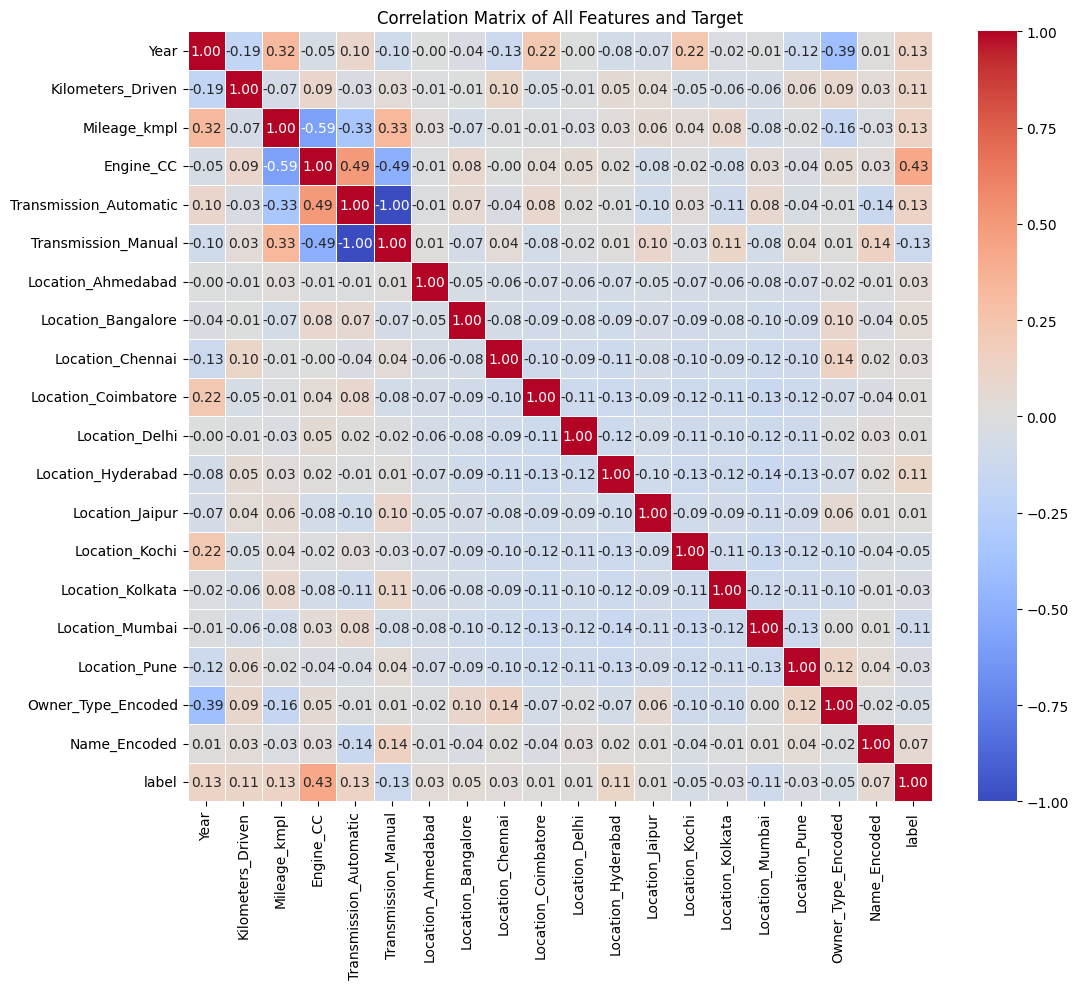

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features (X) and target (y)
X = Cars.drop('label', axis=1)
y = Cars['label']

# Calculate the correlation matrix
correlation_matrix = Cars.corr(numeric_only=True)

# Get correlations with the target variable 'label'
correlation_with_label = correlation_matrix['label'].sort_values(ascending=False)

print("Correlation of Features with 'label' (Fuel Type - Diesel=1, Petrol=0):\n")
print(correlation_with_label)

# Visualize the correlations with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features and Target')
plt.show()

#heat map does not immediately show any very strong correlations

From the correlation analysis, we can identify features that have a strong positive or negative relationship with the `label` (Fuel Type). Features with higher absolute correlation values are generally more relevant. We will consider these correlations when deciding on the final set of features for model training.

### Next Steps for Feature Selection

Since direct linear correlations are not very strong, we should keep in mind that other feature selection methods or models might still find value in these features. Here are a few considerations:

*   **Tree-based Models:** Algorithms like Random Forests or Gradient Boosting can capture non-linear relationships and feature interactions even if individual correlations are low.
*   **Feature Importance from Models:** After training initial models, you can analyze feature importance scores to see which features contribute most to the model's predictions.
*   **Domain Knowledge:** Always consider if a feature is logically important, even if statistics don't immediately show a strong link. For example, `Engine_CC` might still be a key differentiator between fuel types, even if its linear correlation is moderate.

For now, we will retain most features and proceed with data splitting. We can revisit feature selection after training some initial models and evaluating their performance.

## Feature Selection: Univariate Statistical Tests (SelectKBest)

Another common approach to feature selection is to use univariate statistical tests. `SelectKBest` from scikit-learn allows us to select the top 'k' features based on various statistical functions. For classification tasks, `f_classif` (ANOVA F-value) is often used to assess the significance of each feature with respect to the target variable. Higher F-values indicate a stronger relationship.

Top 10 features selected by SelectKBest (f_classif):
Index(['Year', 'Kilometers_Driven', 'Mileage_kmpl', 'Engine_CC',
       'Transmission_Automatic', 'Transmission_Manual', 'Location_Hyderabad',
       'Location_Mumbai', 'Owner_Type_Encoded', 'Name_Encoded'],
      dtype='object')

Feature Scores:
                   Feature        Score
3                Engine_CC  1265.615928
5      Transmission_Manual   104.057427
4   Transmission_Automatic   104.057427
2             Mileage_kmpl   100.695668
0                     Year    94.004105
11      Location_Hyderabad    71.058345
15         Location_Mumbai    64.197190
1        Kilometers_Driven    63.999752
18            Name_Encoded    31.095129
17      Owner_Type_Encoded    24.384873
13          Location_Kochi    16.429519
7       Location_Bangalore    11.960482
16           Location_Pune     9.213491
14        Location_Kolkata     7.749288
6       Location_Ahmedabad     7.365305
8         Location_Chennai     3.895885
12         Location_

/tmp/ipykernel_1631/68628461.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Feature', data=feature_scores_df, palette='magma')


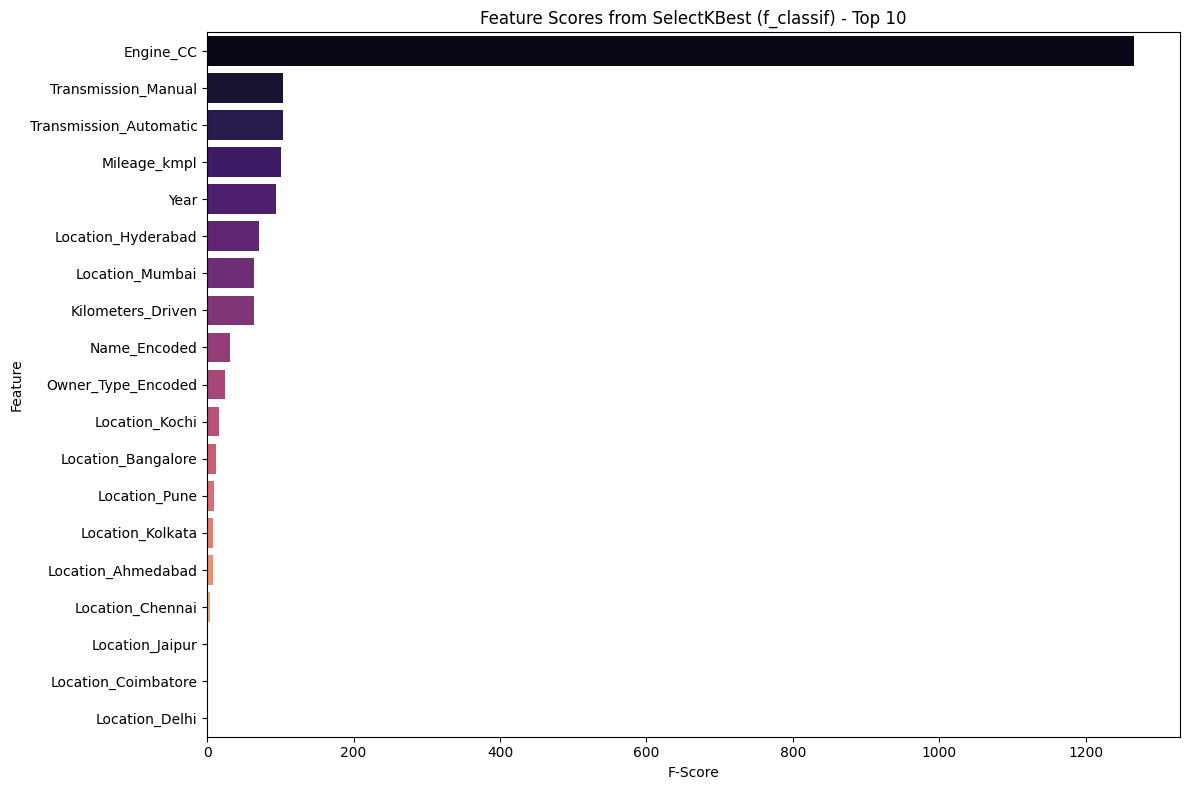

In [177]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X and y are properly defined (from previous cells)
# X = Cars.drop('label', axis=1)
# y = Cars['label']

# Initialize SelectKBest to select the top k features (e.g., top 10 for now)
# You can adjust 'k' based on your preference and the results.
k = 10
selector = SelectKBest(score_func=f_classif, k=k)

# Fit the selector to the training data
selector.fit(X_train, y_train)

# Get the selected features mask
selected_features_mask = selector.get_support()

# Get the names of the selected features
selected_features = X_train.columns[selected_features_mask]

print(f"Top {k} features selected by SelectKBest (f_classif):")
print(selected_features)

# Get the scores for each feature
feature_scores = selector.scores_
feature_scores_df = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})
feature_scores_df = feature_scores_df.sort_values(by='Score', ascending=False)

print("\nFeature Scores:")
print(feature_scores_df)

# Visualize the feature scores
plt.figure(figsize=(12, 8))
sns.barplot(x='Score', y='Feature', data=feature_scores_df, palette='magma')
plt.title(f'Feature Scores from SelectKBest (f_classif) - Top {k}')
plt.xlabel('F-Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

This output shows you the individual F-scores for each feature, indicating their statistical correlation with the target variable. The `selected_features` list contains the top `k` features based on these scores. You can adjust the value of `k` to choose more or fewer features for your model.

## What is Feature Selection?

**Feature selection** is the process of reducing the number of input variables when developing a predictive model. It is important for several reasons:

1.  **Reduces Overfitting:** By removing irrelevant or redundant features, it helps to prevent the model from learning noise in the data, leading to better generalization on unseen data.
2.  **Improves Accuracy:** While seemingly counterintuitive, removing noisy or irrelevant features can sometimes increase the accuracy of the model, especially if those features confuse the learning algorithm.
3.  **Reduces Training Time:** Fewer features mean less data to process, which can significantly speed up the training process of machine learning models.
4.  **Simplifies Models:** A simpler model with fewer features is easier to understand and interpret.
5.  **Reduces Data Collection Costs:** In real-world scenarios, if certain features are found to be irrelevant, you might not need to collect data for them in the future.

### Common Feature Selection Techniques:

There are generally three categories of feature selection methods:

1.  **Filter Methods:** These methods select features based on their statistical properties with respect to the target variable. They evaluate features independently of the machine learning algorithm. Examples include:
    *   **Correlation:** As we did earlier, measuring the linear relationship between features and the target.
    *   **ANOVA F-value (`f_classif`):** What we just used, which measures the statistical significance of differences in means across target classes.
    *   **Chi-squared test:** For categorical features and a categorical target.

2.  **Wrapper Methods:** These methods use a specific machine learning algorithm to evaluate the subset of features. They train a model on different subsets of features and select the subset that yields the best model performance. Examples include:
    *   **Recursive Feature Elimination (RFE):** Iteratively removes features and builds a model, then selects the best performing subset.
    *   **Forward Selection / Backward Elimination:** Adding or removing features one by one and evaluating model performance at each step.

3.  **Embedded Methods:** These methods perform feature selection as part of the model training process itself. The feature selection is 'embedded' within the algorithm. Examples include:
    *   **Lasso (L1 regularization):** Can shrink some feature coefficients to zero, effectively performing feature selection.
    *   **Tree-based models (e.g., Decision Trees, Random Forests):** These models inherently provide feature importance scores, which can be used for selection.

### What to do with the data now?

Based on our `SelectKBest` analysis, we have identified a subset of features that are most statistically relevant to predicting the Fuel Type. The next logical step is to:

1.  **Create a new DataFrame `X_selected`** using only these features.
2.  **Retrain our Decision Tree Classifier (or another model)** using this reduced set of features.
3.  **Compare its performance** to the model trained on all features to see if feature selection improved accuracy or simplified the model without significant performance loss.